# Mode Breaking: 1D Distance Scan — 1 CW vs 2 CWs

Demonstrates how a second CW source breaks the pulsar-distance mode degeneracy.

The pulsar-term phase `phi_p = 2*pi*f*(1-cos_mu)*d/c + const` wraps by 2*pi every
`dL = c / (f * |1 - cos_mu|)` kpc.  With a single CW this produces O(N) equally tall
modes across the EM prior.  A second CW has its own `dL`; both must be simultaneously
satisfied, so coincident modes are rare — unless the two CWs share the same sky patch
(same `cos_mu`, similar `dL`).

| Case | Setup | Expected result |
|------|-------|-----------------|
| **A** | 1 CW | Many ~equal-height modes |
| **B** | 2 CWs, well-separated sky + different freq | Strong mode-breaking: truth = global max |
| **C** | 2 CWs, close sky (~3 deg), different freq | Intermediate: similar `dL` values → weaker breaking |

Target: pulsar with widest EM distance prior (most modes in prior range).

In [27]:
import sys, importlib
sys.path.insert(0, "../CW_lnL_check")

import numpy as np
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import matplotlib.pyplot as plt
import time

import cw_helpers as cwh
importlib.reload(cwh)
from cw_helpers import (
    load_pulsars, inject_noisefree_cw, build_noisefree_likelihood,
    scan_pulsar_distance, analyze_peaks, compute_mode_spacing,
)

## 1. Load pulsars

In [28]:
N_PSR = 5
ent_psrs, disco_psrs = load_pulsars(N_PSR)

sorted_psrs = sorted(disco_psrs, key=lambda p: p.pdist[1])
print("Pulsars sorted by prior sigma:")
print(f"  {'Name':20s}  {'mu (kpc)':>10}  {'sigma (kpc)':>12}  {'n modes in +/-3sigma':>22}")
print("  " + "-" * 72)

# We will show mode count for the single-CW case (computed after CW_A is defined)
for psr in sorted_psrs:
    mu, sig = psr.pdist
    print(f"  {psr.name:20s}  {mu:10.4f}  {sig:12.4f}")

target_psr = sorted_psrs[-1]
print(f"Target (widest prior): {target_psr.name}")
print(f"  mu = {target_psr.pdist[0]:.4f} kpc,  sigma = {target_psr.pdist[1]:.4f} kpc")

FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1855+09.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1937+21.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/B1953+29.feather.
FeatherPulsar.read_feather: cannot find dmx in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cannot find _pdist in feather file /home/mattm/projects/HSYMT/data_products/J0023+0923.feather.
FeatherPulsar.read_feather: cann

## 2. CW injection parameters

CW #1 is identical across all three cases so the same modes appear in Case A.
The second CW varies its sky position to test mode-breaking power.

In [29]:
# Case A: single CW  (used as CW #1 in all cases so mode spacings are comparable)
CW_A = [{"cos_gwtheta":  0.30, "gwphi": 2.50, "cos_inc": -0.2,
          "log10_mc": 9.0, "log10_fgw": -8.0, "log10_h": -12.0,
          "phase0": 1.0, "psi": 0.7}]

# Case B: 2 CWs, well-separated sky + different freq
CW_B = [
    {"cos_gwtheta":  0.30, "gwphi": 2.50, "cos_inc": -0.2,
     "log10_mc": 9.0, "log10_fgw": -8.0, "log10_h": -12.0,
     "phase0": 1.0,  "psi": 0.7},
    {"cos_gwtheta": -0.50, "gwphi": 0.80, "cos_inc":  0.4,
     "log10_mc": 9.0, "log10_fgw": -7.8, "log10_h": -12.0,
     "phase0": 2.1,  "psi": 1.3},
]

# Case C: 2 CWs, close sky (~3 deg apart), different freq
#   Both CWs have nearly the same cos_mu => similar dL => less mode-breaking
CW_C = [
    {"cos_gwtheta":  0.300, "gwphi": 2.500, "cos_inc": -0.2,
     "log10_mc": 9.0, "log10_fgw": -8.0, "log10_h": -12.0,
     "phase0": 1.0,  "psi": 0.7},
    {"cos_gwtheta":  0.285, "gwphi": 2.530, "cos_inc":  0.4,
     "log10_mc": 9.0, "log10_fgw": -7.8, "log10_h": -12.0,
     "phase0": 2.1,  "psi": 1.3},
]

print(f"Mode spacings for target pulsar: {target_psr.name}")
print(f"  {'Case':4s}  {'Src':>4}  {'dL (kpc)':>10}  {'cos_gwtheta':>12}  {'gwphi':>7}  {'log10_fgw':>10}")
print("  " + "-" * 58)
for label, cw_list in [("A", CW_A), ("B", CW_B), ("C", CW_C)]:
    for i, cw in enumerate(cw_list):
        dL = compute_mode_spacing(
            cw["cos_gwtheta"], cw["gwphi"], cw["log10_fgw"], target_psr.pos
        )
        print(f"  {label:4s}  {i+1:4d}  {dL:10.4f}  "
              f"{cw['cos_gwtheta']:12.3f}  {cw['gwphi']:7.3f}  {cw['log10_fgw']:10.2f}")

mu, sig = target_psr.pdist
scan_min = max(0.01, mu - 3.0 * sig)
scan_max = mu + 3.0 * sig
dL_A = compute_mode_spacing(CW_A[0]["cos_gwtheta"], CW_A[0]["gwphi"],
                             CW_A[0]["log10_fgw"], target_psr.pos)
n_modes_A = (scan_max - scan_min) / dL_A
print(f"Prior range: [{scan_min:.3f}, {scan_max:.3f}] kpc  (width = {scan_max-scan_min:.3f} kpc)")
print(f"Case A: dL = {dL_A:.4f} kpc  =>  ~{n_modes_A:.1f} modes in +-3 sigma")

Mode spacings for target pulsar: B1953+29
  Case   Src    dL (kpc)   cos_gwtheta    gwphi   log10_fgw
  ----------------------------------------------------------
  A        1      0.0025         0.300    2.500       -8.00
  B        1      0.0025         0.300    2.500       -8.00
  B        2      0.0012        -0.500    0.800       -7.80
  C        1      0.0025         0.300    2.500       -8.00
  C        2      0.0016         0.285    2.530       -7.80
Prior range: [1.850, 7.430] kpc  (width = 5.580 kpc)
Case A: dL = 0.0025 kpc  =>  ~2226.7 modes in +-3 sigma


## 3. Build likelihoods

Three separate noise-free likelihoods: `num_cw=1` (A) and `num_cw=2` (B, C).
Each has its own injected residuals (sum of all CW signals) and its own JIT graph.

In [30]:
print("Building likelihoods (3x JIT compile, expect ~30-120 s each)...")
t0 = time.time()

residual_map_a, _ = inject_noisefree_cw(disco_psrs, CW_A)
logl_fn_a, param_keys_a, base_values_a = build_noisefree_likelihood(
    disco_psrs, residual_map_a, num_cw=1, cw_params_list=CW_A
)
ta = time.time() - t0
print(f"  A (1 CW):              {ta:.0f} s")

residual_map_b, _ = inject_noisefree_cw(disco_psrs, CW_B)
logl_fn_b, param_keys_b, base_values_b = build_noisefree_likelihood(
    disco_psrs, residual_map_b, num_cw=2, cw_params_list=CW_B
)
tb = time.time() - t0 - ta
print(f"  B (2 CW well-sep):    {tb:.0f} s")

residual_map_c, _ = inject_noisefree_cw(disco_psrs, CW_C)
logl_fn_c, param_keys_c, base_values_c = build_noisefree_likelihood(
    disco_psrs, residual_map_c, num_cw=2, cw_params_list=CW_C
)
tc = time.time() - t0 - ta - tb
print(f"  C (2 CW close-sky):   {tc:.0f} s")

# Warm JIT (first call triggers XLA compilation)
_ = logl_fn_a(base_values_a)
_ = logl_fn_b(base_values_b)
_ = logl_fn_c(base_values_c)
print(f"Total (incl. JIT warm): {time.time()-t0:.0f} s")

print(f"lnL at truth:")
print(f"  A = {float(logl_fn_a(base_values_a)):.2f}")
print(f"  B = {float(logl_fn_b(base_values_b)):.2f}")
print(f"  C = {float(logl_fn_c(base_values_c)):.2f}")

Building likelihoods (3x JIT compile, expect ~30-120 s each)...
  A (1 CW):              1 s
  B (2 CW well-sep):    1 s
  C (2 CW close-sky):   1 s
Total (incl. JIT warm): 6 s
lnL at truth:
  A = 24253.81
  B = 24253.81
  C = 24253.81


## 4. Run 1D scans (n_points = 2000 per case)

In [38]:
mu, sig = target_psr.pdist
scan_min = max(0.01, mu - 3.0 * sig)
scan_max = mu + 3.0 * sig
N_POINTS = 2000*100
dist_key = f"{target_psr.name}_cw_p_dist"

print(f"Scanning {target_psr.name}  [{scan_min:.3f}, {scan_max:.3f}] kpc  ({N_POINTS} pts)")
t0 = time.time()

scan_d_a, scan_ll_a = scan_pulsar_distance(
    logl_fn_a, base_values_a, param_keys_a, dist_key, scan_min, scan_max, N_POINTS, required_points=[mu]
)
ta = time.time() - t0
print(f"  A done: {ta:.1f} s")

scan_d_b, scan_ll_b = scan_pulsar_distance(
    logl_fn_b, base_values_b, param_keys_b, dist_key, scan_min, scan_max, N_POINTS, required_points=[mu]
)
tb = time.time() - t0 - ta
print(f"  B done: {tb:.1f} s")

scan_d_c, scan_ll_c = scan_pulsar_distance(
    logl_fn_c, base_values_c, param_keys_c, dist_key, scan_min, scan_max, N_POINTS, required_points=[mu]
)
print(f"  C done: {time.time()-t0-ta-tb:.1f} s")
print(f"Total scan: {time.time()-t0:.1f} s")


Scanning B1953+29  [1.850, 7.430] kpc  (200000 pts)
  A done: 7.4 s
  B done: 7.8 s
  C done: 7.9 s
Total scan: 23.1 s


## 5. Peak analysis

`analyze_peaks` uses `scipy.signal.find_peaks` with adaptive prominence.
*truth vs global* < 0 means the truth distance is not the global maximum.

In [39]:
mu, sig = target_psr.pdist

dL_A = compute_mode_spacing(CW_A[0]["cos_gwtheta"], CW_A[0]["gwphi"],
                             CW_A[0]["log10_fgw"], target_psr.pos)
dL_B = min(compute_mode_spacing(cw["cos_gwtheta"], cw["gwphi"],
                                 cw["log10_fgw"], target_psr.pos) for cw in CW_B)
dL_C = min(compute_mode_spacing(cw["cos_gwtheta"], cw["gwphi"],
                                 cw["log10_fgw"], target_psr.pos) for cw in CW_C)

pk_a = analyze_peaks(scan_d_a, scan_ll_a, mu, mode_spacing=dL_A)
pk_b = analyze_peaks(scan_d_b, scan_ll_b, mu, mode_spacing=dL_B)
pk_c = analyze_peaks(scan_d_c, scan_ll_c, mu, mode_spacing=dL_C)

truth_ll_a = float(np.interp(mu, scan_d_a, scan_ll_a))
truth_ll_b = float(np.interp(mu, scan_d_b, scan_ll_b))
truth_ll_c = float(np.interp(mu, scan_d_c, scan_ll_c))
truth_rank_a = truth_ll_a - np.max(scan_ll_a)
truth_rank_b = truth_ll_b - np.max(scan_ll_b)
truth_rank_c = truth_ll_c - np.max(scan_ll_c)

print(f"Peak analysis: {target_psr.name}  (truth d = {mu:.4f} kpc)")
print(f"  {'Case':22s}  {'n_peaks':>8}  {'truth vs global max':>20}  {'truth vs best-wrong':>20}")
print("  " + "-" * 78)
for label, pk, tr_rank in [
    ("A  (1 CW)",            pk_a, truth_rank_a),
    ("B  (2 CW well-sep)",   pk_b, truth_rank_b),
    ("C  (2 CW close-sky)",  pk_c, truth_rank_c),
]:
    d = pk["delta_lnL_truth_vs_best_wrong"]
    d_str = f"{d:+.2f}" if not np.isnan(d) else "no other peaks"
    print(f"  {label:22s}  {pk['n_peaks']:8d}  {tr_rank:+20.2f}  {d_str:>20}")

print()
print("truth vs global < 0  =>  truth is not the global maximum")
print("truth vs best-wrong  =>  how much better truth is than the tallest wrong mode")

Peak analysis: B1953+29  (truth d = 4.6400 kpc)
  Case                     n_peaks   truth vs global max   truth vs best-wrong
  ------------------------------------------------------------------------------
  A  (1 CW)                   7880                 +0.00                 +0.01
  B  (2 CW well-sep)          8973                 +0.00                 +1.17
  C  (2 CW close-sky)         8770                 +0.00                 +0.72

truth vs global < 0  =>  truth is not the global maximum
truth vs best-wrong  =>  how much better truth is than the tallest wrong mode


## 6. Overlay plot — all 3 cases on the same axes

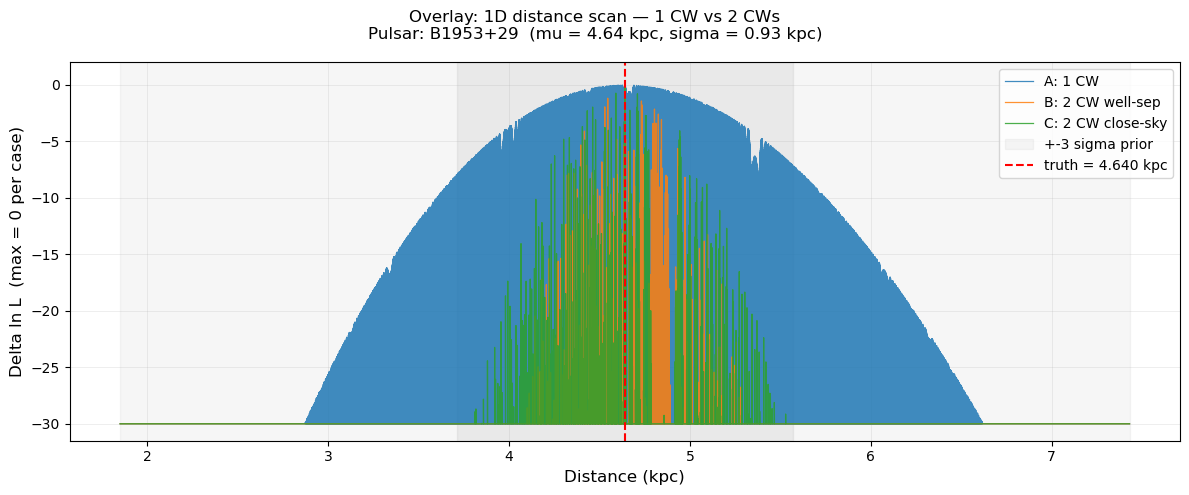

In [40]:
# ── Overlay: all 3 cases on the same axes ────────────────────────────────────
mu, sig = target_psr.pdist
scan_min = max(0.01, mu - 3.0 * sig)
scan_max = mu + 3.0 * sig

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(
    f"Overlay: 1D distance scan — 1 CW vs 2 CWs\n"
    f"Pulsar: {target_psr.name}  "
    f"(mu = {mu:.2f} kpc, sigma = {sig:.2f} kpc)",
    fontsize=12,
)

clip_min = -30.0
for label, sd, sl, col, ls in [
    ("A: 1 CW",             scan_d_a, scan_ll_a, "C0", "-"),
    ("B: 2 CW well-sep",    scan_d_b, scan_ll_b, "C1", "-"),
    ("C: 2 CW close-sky",   scan_d_c, scan_ll_c, "C2", "-"),
]:
    sl_norm = sl - np.max(sl)
    ax.plot(sd, np.clip(sl_norm, clip_min, 0), color=col, lw=0.9, ls=ls,
            alpha=0.85, label=label)

# Prior shading
ax.axvspan(scan_min, scan_max, alpha=0.07, color="gray", label="+-3 sigma prior")
ax.axvspan(max(0.01, mu - sig), mu + sig, alpha=0.10, color="gray")
ax.axvline(mu, color="red", lw=1.5, ls="--", label=f"truth = {mu:.3f} kpc")

ax.set_xlabel("Distance (kpc)", fontsize=12)
ax.set_ylabel("Delta ln L  (max = 0 per case)", fontsize=12)
ax.set_ylim(clip_min * 1.05, 2.0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, lw=0.5)
plt.tight_layout()
plt.show()

## 7. Three-panel figure

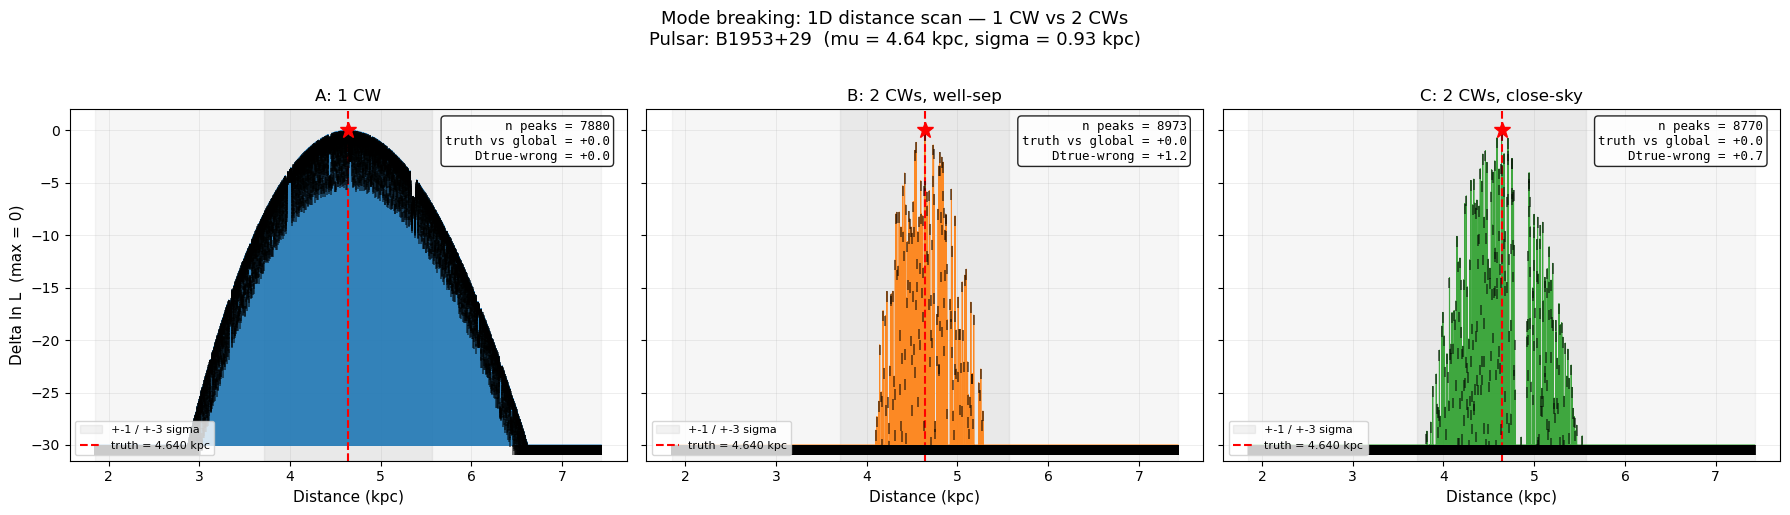

Saved: 01b_mode_breaking_3panel.pdf


In [41]:
# ── 3-panel figure ────────────────────────────────────────────────────────────
mu, sig = target_psr.pdist

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle(
    f"Mode breaking: 1D distance scan — 1 CW vs 2 CWs\n"
    f"Pulsar: {target_psr.name}  "
    f"(mu = {mu:.2f} kpc, sigma = {sig:.2f} kpc)",
    fontsize=13, y=1.02,
)

clip_min = -30.0
cases = [
    ("A: 1 CW",             scan_d_a, scan_ll_a, pk_a, "C0", truth_rank_a),
    ("B: 2 CWs, well-sep",  scan_d_b, scan_ll_b, pk_b, "C1", truth_rank_b),
    ("C: 2 CWs, close-sky", scan_d_c, scan_ll_c, pk_c, "C2", truth_rank_c),
]

for ax, (title, sd, sl, pk, col, tr_rank) in zip(axes, cases):
    sl_norm = sl - np.max(sl)
    sl_plot = np.clip(sl_norm, clip_min, 0)

    ax.plot(sd, sl_plot, color=col, lw=0.8, alpha=0.9)

    ax.axvspan(max(0.01, mu - 3*sig), mu + 3*sig, alpha=0.07, color="gray")
    ax.axvspan(max(0.01, mu - sig),   mu + sig,   alpha=0.10, color="gray",
               label="+-1 / +-3 sigma")
    ax.axvline(mu, color="red", lw=1.5, ls="--", label=f"truth = {mu:.3f} kpc")
    truth_norm = float(np.interp(mu, sd, sl_norm))
    ax.plot(mu, np.clip(truth_norm, clip_min, 0), "r*", ms=12, zorder=5)

    # Mark all peaks
    if len(pk["peak_distances"]) > 0:
        ph_norm = pk["peak_heights"] - np.max(sl)
        ph_plot = np.clip(ph_norm, clip_min, 0)
        ax.vlines(pk["peak_distances"], ph_plot - 1.0, ph_plot,
                  color="k", lw=1.2, alpha=0.6)

    # Annotation box
    delta = pk["delta_lnL_truth_vs_best_wrong"]
    d_str = f"Dtrue-wrong = {delta:+.1f}" if not np.isnan(delta) else "no other peaks"
    ann = (f"n peaks = {pk['n_peaks']}\n"
           f"truth vs global = {tr_rank:+.1f}\n"
           f"{d_str}")
    ax.text(0.97, 0.97, ann,
            transform=ax.transAxes, ha="right", va="top",
            fontsize=9, family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))

    ax.set_xlabel("Distance (kpc)", fontsize=11)
    if ax is axes[0]:
        ax.set_ylabel("Delta ln L  (max = 0)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.set_ylim(clip_min * 1.05, 2.0)
    ax.legend(fontsize=8, loc="lower left")
    ax.grid(True, alpha=0.3, lw=0.5)

plt.tight_layout()
plt.savefig("01b_mode_breaking_3panel.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: 01b_mode_breaking_3panel.pdf")